# Ensemble methods on Titanic 🚢🚢

## Introduction

This exercise is the opportunity to practice ensemble methods on a dataset you have worked with before and that is the Titanic dataset.

Let's start by importing the librairies that we will used in the exercise.

In [1]:
!pip install -q s3fs

In [131]:
# Load in our libraries
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import ensemble methods
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

## Feature Exploration, Engineering and Cleaning 

1. Import the data using the following link : "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/stacking/titanic.csv" , and display the first lines. Are there any missing values in the dataset?

In [59]:
df = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/stacking/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


2. What types of variables are present in this dataset? What kind of preprocessing could you run on these variables?

3. Here are some guidelines you can follow to clean the dataset as well as create new variables (feature engineering).

a.  Create a Name_length variable that measures the number of characters in the variable Name for each observations.

In [ ]:
df['Name_length'] = [len(name) for name in df["Name"]]  #data['Name_length'] = data['Name'].apply(len)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_length
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,23
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,51
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,22
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,44
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,24


b. Create a variable Has_Cabin that indicates whether the passenger has a cabin or not.

Hint: [this method](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.notna.html#pandas.DataFrame.notna) might be useful 😉

In [ ]:
df["Has_Cabin"] = (~df["Cabin"].isnull())  # data['Has_Cabin'] = data["Cabin"].notna()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_length,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,23,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,51,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,22,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,44,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,24,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,21,False
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,28,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,40,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,21,True


c. Create a variable FamilySize that gives the size of each passenger's family.

In [ ]:
df["FamilySize"] = df["SibSp"] + 1  #data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_length,Has_Cabin,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,23,False,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,51,True,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,22,False,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,44,True,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,24,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,21,False,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,28,True,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,40,False,2
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,21,True,1


d. Create a variable IsAlone that indicates whether the passenger is traveling on their own.

In [ ]:
# data['IsAlone'] = False
# data.loc[data['FamilySize'] == 1, 'IsAlone'] = True
df["IsAlone"] = df["SibSp"] == 0
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_length,Has_Cabin,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,23,False,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,51,True,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,22,False,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,44,True,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,24,False,1,True


h. Extract the title from each passenger in order to create a variable Title.

Hint: You might consider _applying_ a function that calls the [str.split method](https://docs.python.org/3.3/library/stdtypes.html?highlight=split#str.split) 😉

In [ ]:
# # Define function to extract titles from passenger names
# def get_title(name):
#     return name.split(", ")[1].split(".")[0]

# # Create a new feature Title, containing the titles of passenger names
# data['Title'] = data['Name'].apply(get_title)
df["Title"] = df["Name"].str.split(',').str[1].str.split('.').str[0].str.strip()
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Name_length,Has_Cabin,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,23,False,2,False,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,51,True,2,False,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,22,False,1,True,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,44,True,2,False,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,24,False,1,True,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,21,False,1,True,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,28,True,1,True,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,40,False,2,False,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,21,True,1,True,Mr


i. If some of these titles are equivalent convert them in order to bring them all in the same category.

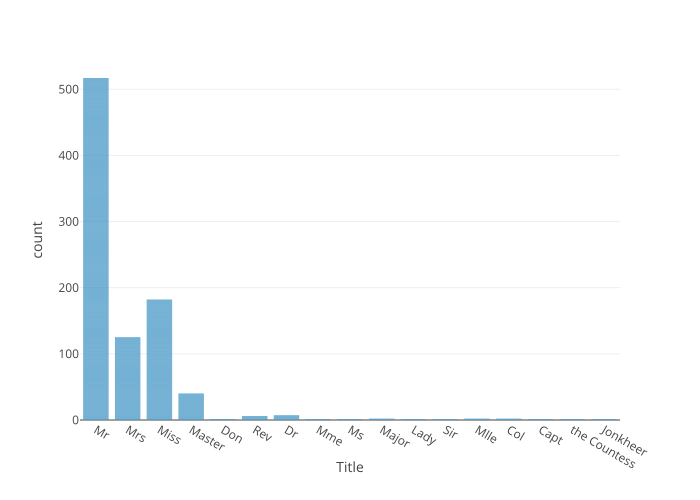

In [67]:
fig1 = px.bar(df, x="Title")
fig1.show()

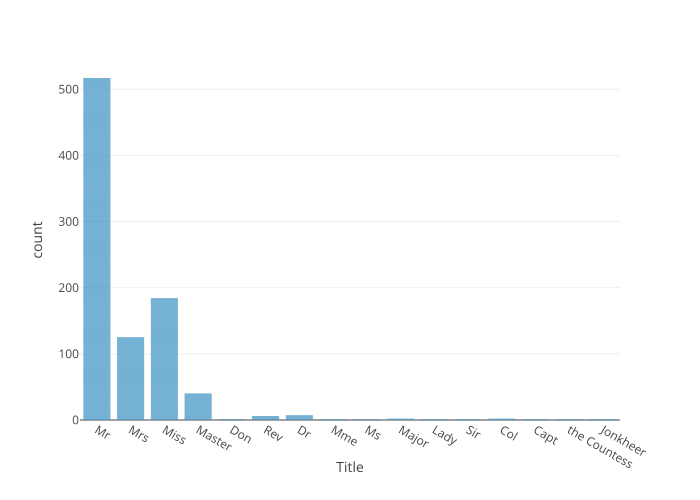

In [68]:
df["Title"].replace({"Mlle": "Miss"}, inplace=True)
fig2 = px.bar(df, x="Title")
fig2.show()

j. Are any of the remaining titles underrepresented among the observations? If it is the case, group them in a unique modality "Rare"

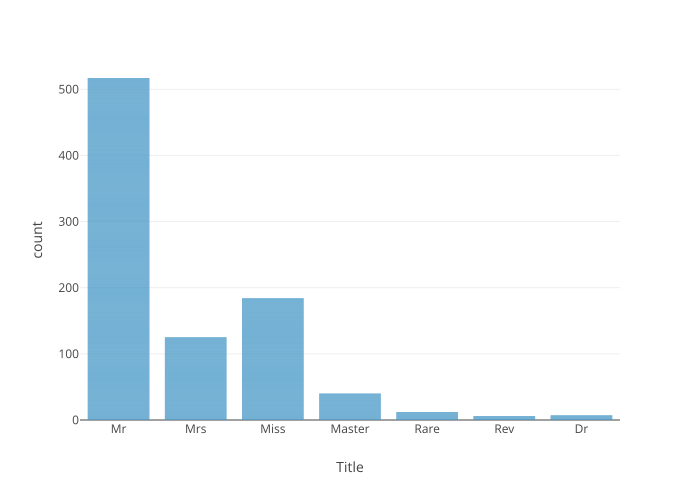

In [69]:
df["Title"].replace(["Don", "Ms", "Mme", "Major", "Lady", "Sir", "Col", "Capt", "the Countess", "Jonkheer"], "Rare", inplace=True)
fig3 = px.bar(df, x="Title")
fig3.show()

4. Drop the columns 'PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp' du dataset. Why don't we need these columns for what's next?

In [70]:
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin", "SibSp"], axis=1)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    object 
 3   Age          714 non-null    float64
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Embarked     889 non-null    object 
 7   Name_length  891 non-null    int64  
 8   Has_Cabin    891 non-null    bool   
 9   FamilySize   891 non-null    int64  
 10  IsAlone      891 non-null    bool   
 11  Title        891 non-null    object 
dtypes: bool(2), float64(2), int64(5), object(3)
memory usage: 71.5+ KB


5. Separate the features from the target and split the data between train and test (with random_state = 0)

In [73]:
X = df.iloc[:, 1:]
Y = df.iloc[:, 0]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

6. Using the Pipeline and ColumnTransformer, make all the preprocessings at once. Use the [KNN imputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) to handle the missing values in the numeric variables, and the SimpleImputer for categorical data.

In [ ]:
# numeric_features = []
# categorical_features = []
# # Assurez-vous que X est votre DataFrame
# for col_name in X.columns:
#     dtype = X[col_name].dtype
#     if dtype in ['int64', 'float64']:
#         numeric_features.append(col_name)
#     elif dtype == 'bool':
#         numeric_features.append(col_name)  # Ou categorical_features.append(col_name) selon le traitement souhaité
#     else:  # pour 'object' et d'autres types non numériques
#         categorical_features.append(col_name)

numerical_features = []
categorical_features = []

for i, t in X.dtypes.items():
    if ("float" in str(t)) or ("int" in str(t)):
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print("Found numeric features", numerical_features)
print("Found categorical features", categorical_features)

Found numeric features ['Pclass', 'Age', 'Parch', 'Fare', 'Name_length', 'FamilySize']
Found categorical features ['Sex', 'Embarked', 'Has_Cabin', 'IsAlone', 'Title']


In [ ]:
print("Performing preprocessings on train set...")
print(X_train.head())
numeric_transformers = Pipeline(
    steps=[
        ("imputer", KNNImputer()),
        ("scaler", StandardScaler())
    ]
)

categorical_transformers = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(drop='first'))
    ]
)

preprocessor = ColumnTransformer([
    ("num", numeric_transformers, numerical_features),
    ("cat", categorical_transformers, categorical_features)
])
X_train = preprocessor.fit_transform(X_train)
print("...Done")
print(X_train[:5])
print()
print("Performing preprocessings on test set...")
print(X_test.head())
X_test= preprocessor.transform(X_test)
print("...Done")
print(X_test[:5])

Performing preprocessings on train set...
     Pclass     Sex   Age  Parch     Fare Embarked  Name_length  Has_Cabin  \
140       3  female   NaN      2  15.2458        C           29      False   
439       2    male  31.0      0  10.5000        S           38      False   
817       2    male  31.0      1  37.0042        C           18      False   
378       3    male  20.0      0   4.0125        C           19      False   
491       3    male  21.0      0   7.2500        S           19      False   

     FamilySize  IsAlone Title  
140           1     True   Mrs  
439           1     True    Mr  
817           2    False    Mr  
378           1     True    Mr  
491           1     True    Mr  
...Done
[[ 0.81925059 -0.34315413  1.95926403 -0.33167904  0.20275622 -0.46445234
   1.          0.          1.          0.          0.          1.
   0.          0.          1.          0.          0.          0.
   0.          1.          0.          0.        ]
 [-0.38096838  0.06490866 

### Pearson Correlation Heatmap

7. Produce a figure that contains the correlation table for all the explanatory variables of X_train, what do you think?

In [83]:
X_train

array([[ 0.81925059, -0.34315413,  1.95926403, ...,  1.        ,
         0.        ,  0.        ],
       [-0.38096838,  0.06490866, -0.47741019, ...,  0.        ,
         0.        ,  0.        ],
       [-0.38096838,  0.06490866,  0.74092692, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.81925059,  0.00555407, -0.47741019, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.81925059,  0.43587483, -0.47741019, ...,  1.        ,
         0.        ,  0.        ],
       [-0.38096838,  2.21651243,  0.74092692, ...,  0.        ,
         0.        ,  0.        ]])

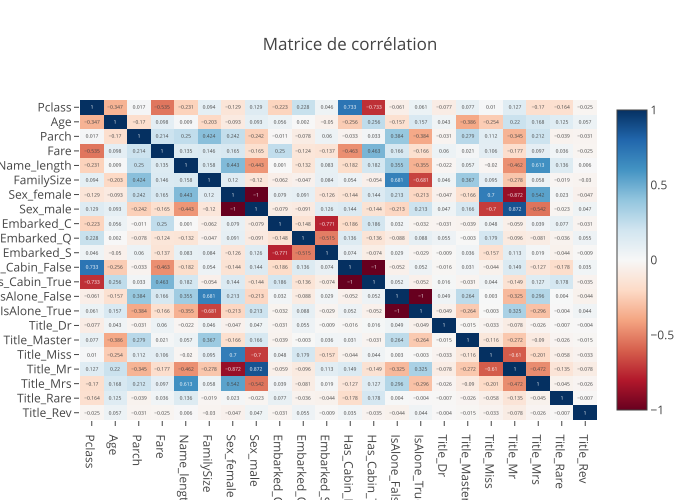

In [ ]:
# # Correlation matrix
# corr_matrix = pd.DataFrame(X_train).corr().round(2)

# import plotly.figure_factory as ff

# fig = ff.create_annotated_heatmap(corr_matrix.values,
#                                   x = corr_matrix.columns.tolist(),
#                                   y = corr_matrix.index.tolist())


# fig.show()


# Convertir en DataFrame si nécessaire
feature_names = preprocessor.get_feature_names_out()
feature_names = [x[5:] for x in feature_names]
df_train = pd.DataFrame(X_train, columns=feature_names)
correlation_matrix = df_train.corr().round(3)

heatmap = px.imshow(correlation_matrix, 
                    text_auto=True,
                    color_continuous_scale='RdBu',
                    title="Matrice de corrélation",
                    aspect="auto",
                    color_continuous_midpoint=0)

heatmap.update_layout(width=2500, height=1500, autosize=False)       # Taille fixe si nécessaire
heatmap.show()

**Correlations between the variables are not very high, we can hope that they will each bring complementary information in order to predict the target variable.**

## Ensembling & Stacking models

Now that we have finished our preprocessing and made sure our data was fit for prediction, let's move on to creating our ensemble models. We'll train different models with different ensembling strategies and store their train and test scores for comparison.

### Random Forest
8. Train a Random Forest by tuning the hyperparameters with a grid search. Which ensemble method is related to random forests?

Evaluate the best model's accuracy on train and test sets. Save the scores into a pandas DataFrame.

In [ ]:
# scores_df = pd.DataFrame(columns = ['model', 'accuracy', 'set'])

# scores_df = scores_df.append({'model': 'random_forest', 'accuracy': gridsearch.score(X_train, y_train), 'set': 'train'}, ignore_index = True)
# scores_df = scores_df.append({'model': 'random_forest', 'accuracy': gridsearch.score(X_test, y_test), 'set': 'test'}, ignore_index = True)
# scores_df

# new_rows = [
#     {'model': 'random_forest', 'accuracy': gridsearch.score(X_train, y_train), 'set': 'train'},
#     {'model': 'random_forest', 'accuracy': gridsearch.score(X_test, y_test), 'set': 'test'}
# ]


# scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
# scores_df

In [128]:
# Perform grid search
print("Grid search...")
random_forest = RandomForestClassifier()
# model = BaggingClassifier(estimator=random_forest)

# Grid of values to be tested
params = {
    "max_depth": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 4, 8],
    "n_estimators": [10, 20, 40, 60, 80, 100]
}
print(params)
gridsearch = GridSearchCV(random_forest, param_grid=params, cv=3, verbose=1)
gridsearch.fit(X_train, Y_train)

print("...Done")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, Y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, Y_test))

train_accuracy = gridsearch.score(X_train, Y_train)
test_accuracy = gridsearch.score(X_test, Y_test)

predictions = pd.DataFrame({
    "model": ["Random Forest", "Random Forest"],
    "accuracy": [train_accuracy, test_accuracy],
    "set": ["train", "test"]
})
predictions

Grid search...
{'max_depth': [2, 4, 6, 8, 10], 'min_samples_leaf': [1, 2, 5], 'min_samples_split': [2, 4, 8], 'n_estimators': [10, 20, 40, 60, 80, 100]}
Fitting 3 folds for each of 270 candidates, totalling 810 fits
...Done
Best hyperparameters :  {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 40}
Best validation accuracy :  0.8385041780425251

Accuracy on training set :  0.8918539325842697
Accuracy on test set :  0.8379888268156425


,model,accuracy,set
0,Random Forest,0.891854,train
1,Random Forest,0.837989,test


9. Create your own Bagging of decision tree (with the same hyperparameters as the optimal ones for Random Forest) and check you get compatible performances.

In [ ]:
# print('Training Bagging of decision tree...')
# decision_tree = DecisionTreeClassifier(max_depth = 8, min_samples_leaf = 1, min_samples_split = 4) # Same hyperparameters as best RF model
# bagging = BaggingClassifier(estimator=decision_tree, n_estimators = 20)
# bagging.fit(X_train, y_train)
# print("...Done.")

# Perform grid search
print("Grid search...")
decision_tree = DecisionTreeClassifier()
model = BaggingClassifier(estimator=decision_tree)

# Grid of values to be tested
params = {
    "estimator__max_depth": [8],
    "estimator__min_samples_leaf": [2],
    "estimator__min_samples_split": [2],
    "n_estimators": [40]
}
print(params)
gridsearch = GridSearchCV(model, param_grid=params, cv=3, verbose=1)
gridsearch.fit(X_train, Y_train)

print("...Done")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, Y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, Y_test))

train_accuracy = gridsearch.score(X_train, Y_train)
test_accuracy = gridsearch.score(X_test, Y_test)

predictions_dt = pd.DataFrame({
    "model": ["bagging_dt", "bagging_dt"],
    "accuracy": [train_accuracy, test_accuracy],
    "set": ["train", "test"]
})
predictions = pd.concat([predictions, predictions_dt], ignore_index=True)
predictions

Grid search...
{'estimator__max_depth': [8], 'estimator__min_samples_leaf': [2], 'estimator__min_samples_split': [2], 'n_estimators': [40]}
Fitting 3 folds for each of 1 candidates, totalling 3 fits
...Done
Best hyperparameters :  {'estimator__max_depth': 8, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'n_estimators': 40}
Best validation accuracy :  0.8300771785507451

Accuracy on training set :  0.9129213483146067
Accuracy on test set :  0.8324022346368715


,model,accuracy,set
0,Random Forest,0.891854,train
1,Random Forest,0.837989,test
2,bagging_dt,0.912921,train
3,bagging_dt,0.832402,test


10. Train an AdaBoost model by tuning the hyperparameters:
* With a logistic regression as base estimator
* With a decision tree as base estimator

For each model, evaluate the performances on the test set.

In [ ]:
# params = {
#     'estimator__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
#     'n_estimators': [5, 10, 20, 40, 60, 80, 100]
# }

# Perform grid search
print("Grid search...")
LogisticRegression = LogisticRegression(max_iter=1000)
model = AdaBoostClassifier(estimator=LogisticRegression)

# Grid of values to be tested
params = {
    "estimator__C": [
        0.01,
        0.05,
        0.1,
        0.5,
    ],  # base_estimator__ prefix because C is a parameter from LogisticRegression!
    "n_estimators": [
        5,
        10,
        20,
        30,
    ],  # n_estimators is a hyperparameter of the ensemble method
}
print(params)
gridsearch = GridSearchCV(model, param_grid=params, cv=3, verbose=1)
gridsearch.fit(X_train, Y_train)

print("...Done")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, Y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, Y_test))

train_accuracy = gridsearch.score(X_train, Y_train)
test_accuracy = gridsearch.score(X_test, Y_test)

predictions_ada_log = pd.DataFrame({
    "model": ["adaboost_logreg", "adaboost_logreg"],
    "accuracy": [train_accuracy, test_accuracy],
    "set": ["train", "test"]
})
predictions = pd.concat([predictions, predictions_ada_log], ignore_index=True)
predictions

Grid search...
{'estimator__C': [0.01, 0.05, 0.1, 0.5], 'n_estimators': [5, 10, 20, 30]}
Fitting 3 folds for each of 16 candidates, totalling 48 fits
...Done
Best hyperparameters :  {'estimator__C': 0.01, 'n_estimators': 30}
Best validation accuracy :  0.8160006618681228

Accuracy on training set :  0.8033707865168539
Accuracy on test set :  0.8100558659217877


,model,accuracy,set
0,Random Forest,0.891854,train
1,Random Forest,0.837989,test
2,bagging_dt,0.912921,train
3,bagging_dt,0.832402,test
4,adaboost_logreg,0.803371,train
5,adaboost_logreg,0.810056,test


In [ ]:
# params = {
#     'estimator__max_depth': [8, 10, 12],
#     'estimator__min_samples_leaf': [1, 2, 3],
#     'estimator__min_samples_split': [6, 8, 10],
#     'n_estimators': [2, 4, 6, 8, 10, 12]
# }

# Perform grid search
print("Grid search...")
decision_tree = DecisionTreeClassifier()
model = AdaBoostClassifier(estimator=decision_tree)

# Grid of values to be tested
params = {
    "estimator__max_depth": [8],
    "estimator__min_samples_leaf": [2],
    "estimator__min_samples_split": [2],
    "n_estimators": [40]
}
print(params)
gridsearch = GridSearchCV(model, param_grid=params, cv=3, verbose=1)
gridsearch.fit(X_train, Y_train)

print("...Done")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, Y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, Y_test))

train_accuracy = gridsearch.score(X_train, Y_train)
test_accuracy = gridsearch.score(X_test, Y_test)

predictions_ada_dt = pd.DataFrame({
    "model": ["adaboost_dt", "adaboost_dt"],
    "accuracy": [train_accuracy, test_accuracy],
    "set": ["train", "test"]
})
predictions = pd.concat([predictions, predictions_ada_dt], ignore_index=True)
predictions

Grid search...
{'estimator__max_depth': [8], 'estimator__min_samples_leaf': [2], 'estimator__min_samples_split': [2], 'n_estimators': [40]}
Fitting 3 folds for each of 1 candidates, totalling 3 fits
...Done
Best hyperparameters :  {'estimator__max_depth': 8, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'n_estimators': 40}
Best validation accuracy :  0.7837050431987141

Accuracy on training set :  0.9971910112359551
Accuracy on test set :  0.8324022346368715


,model,accuracy,set
0,Random Forest,0.891854,train
1,Random Forest,0.837989,test
2,bagging_dt,0.912921,train
3,bagging_dt,0.832402,test
4,adaboost_logreg,0.803371,train
5,adaboost_logreg,0.810056,test
6,adaboost_dt,0.997191,train
7,adaboost_dt,0.832402,test


11. Train scikit-learn's GradientBoosting model (by tuning hyperparameters) and evaluate the performances.

In [ ]:
# params = {
#     'max_depth': [8, 10, 12],
#     'min_samples_leaf': [1, 2, 3],
#     'min_samples_split': [6, 8, 10],
#     'n_estimators': [2, 4, 6, 8, 10, 12]
# }

# Perform grid search
print("Grid search...")
model = GradientBoostingClassifier()

# Grid of values to be tested
params = {
    "max_depth": [
        1,
        2,
        3,
    ],  # no base_estimator_ prefix because these are all arguments of GradientBoostingClassifier
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4],
    "n_estimators": [2, 4, 6, 8, 10],
}
print(params)
gridsearch = GridSearchCV(model, param_grid=params, cv=3, verbose=1)
gridsearch.fit(X_train, Y_train)

print("...Done")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, Y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, Y_test))

train_accuracy = gridsearch.score(X_train, Y_train)
test_accuracy = gridsearch.score(X_test, Y_test)

predictions_gradient_boost = pd.DataFrame({
    "model": ["gradient_boost", "gradient_boost"],
    "accuracy": [train_accuracy, test_accuracy],
    "set": ["train", "test"]
})
predictions = pd.concat([predictions, predictions_gradient_boost], ignore_index=True)
predictions

Grid search...
{'max_depth': [1, 2, 3], 'min_samples_leaf': [1, 2, 3], 'min_samples_split': [2, 3, 4], 'n_estimators': [2, 4, 6, 8, 10]}
Fitting 3 folds for each of 135 candidates, totalling 405 fits
...Done
Best hyperparameters :  {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 10}
Best validation accuracy :  0.8202496188348757

Accuracy on training set :  0.851123595505618
Accuracy on test set :  0.7988826815642458


,model,accuracy,set
0,Random Forest,0.891854,train
1,Random Forest,0.837989,test
2,bagging_dt,0.912921,train
3,bagging_dt,0.832402,test
4,adaboost_logreg,0.803371,train
5,adaboost_logreg,0.810056,test
6,adaboost_dt,0.997191,train
7,adaboost_dt,0.832402,test
8,gradient_boost,0.851124,train
9,gradient_boost,0.798883,test


12. Train an XGBoost model (by tuning hyperparameters). Do you get better or similar results compared to scikit-learn's GradientBoosting?

In [ ]:
# params = {
#     'max_depth': [4, 6, 8, 10],
#     'min_child_weight': [1, 2, 4, 6, 8],
#     'n_estimators': [2, 4, 6, 8, 10, 12]
# }

# Perform grid search
print("Grid search...")
xgboost = XGBClassifier()

# Grid of values to be tested
params = {
    "max_depth": [2, 4, 6],  # exactly the same role as in scikit-learn
    "min_samples_leaf": [
        1,
        2,
        3,
    ],  # effect is more or less similar to min_samples_leaf and min_samples_split
    "n_estimators": [
        2,
        4,
        6,
        8,
    ],  # exactly the same role as in scikit-learn
}
print(params)
gridsearch = GridSearchCV(model, param_grid=params, cv=3, verbose=1)
gridsearch.fit(X_train, Y_train)

print("...Done")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, Y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, Y_test))

train_accuracy = gridsearch.score(X_train, Y_train)
test_accuracy = gridsearch.score(X_test, Y_test)

predictions_xgboost = pd.DataFrame({
    "model": ["xgboost", "xgboost"],
    "accuracy": [train_accuracy, test_accuracy],
    "set": ["train", "test"]
})
predictions = pd.concat([predictions, predictions_xgboost], ignore_index=True)
predictions

Grid search...
{'max_depth': [2, 4, 6], 'min_samples_leaf': [1, 2, 3], 'n_estimators': [2, 4, 6, 8]}
Fitting 3 folds for each of 36 candidates, totalling 108 fits
...Done
Best hyperparameters :  {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 8}
Best validation accuracy :  0.8202141616140127

Accuracy on training set :  0.8637640449438202
Accuracy on test set :  0.7988826815642458


,model,accuracy,set
0,Random Forest,0.891854,train
1,Random Forest,0.837989,test
2,bagging_dt,0.912921,train
3,bagging_dt,0.832402,test
4,adaboost_logreg,0.803371,train
5,adaboost_logreg,0.810056,test
6,adaboost_dt,0.997191,train
7,adaboost_dt,0.832402,test
8,gradient_boost,0.851124,train
9,gradient_boost,0.798883,test


13. Compare all the models' performances in a bar chart and conclude. Which model is the best?

Hint: the option `barmode` in plotly's `px.bar()` might be useful 😇

In [138]:
predictions = predictions.sort_values(["set","accuracy"], ascending=False)
predictions

,model,accuracy,set
6,adaboost_dt,0.997191,train
2,bagging_dt,0.912921,train
0,Random Forest,0.891854,train
10,xgboost,0.863764,train
8,gradient_boost,0.851124,train
4,adaboost_logreg,0.803371,train
1,Random Forest,0.837989,test
3,bagging_dt,0.832402,test
7,adaboost_dt,0.832402,test
5,adaboost_logreg,0.810056,test


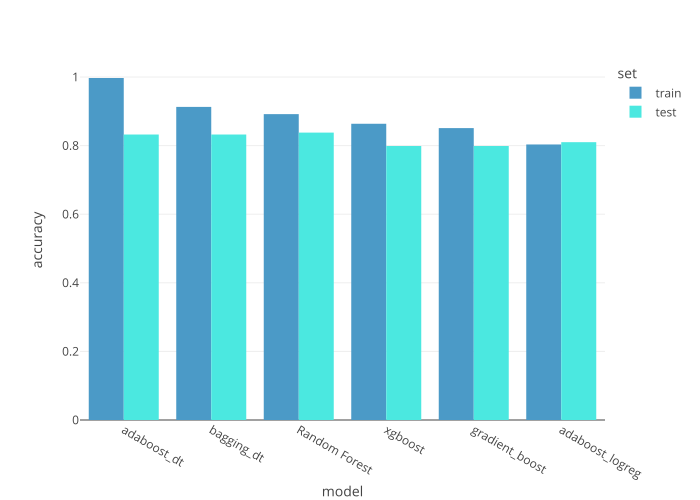

In [141]:
fig_model = px.bar(predictions, x="model", y="accuracy", color="set", barmode="group", width=900)
fig_model.show()

The gradient boosting model seems to be a bit better than the other ones: it has the best test accuracy and still doesn't overfit that much.